In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/allsides_balanced_news_headlines-texts.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (21754, 7)

Columns:
['Unnamed: 0', 'title', 'tags', 'heading', 'source', 'text', 'bias_rating']


,Unnamed: 0,title,tags,heading,source,text,bias_rating
0,0,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",Chicago Gun Violence Spikes and Increasingly F...,New York Times (News),As Yasmin Miller drove home from a laundromat ...,left
1,1,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",‘Bullets just came from nowhere’: Fourth of Ju...,Chicago Tribune,As many Chicagoans were celebrating the Fourth...,center
2,2,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",Dozens of shootings across US mark bloody July...,New York Post (News),The nation’s 4th of July weekend was marred by...,right
3,3,Yellen Warns Congress of 'Economic Recession' ...,"['Janet Yellen', 'Debt Ceiling', 'Economic Pol...",Federal Government Will Run Out of Cash on Oct...,The Epoch Times,Treasury Secretary Janet Yellen on Tuesday war...,right
4,4,Yellen Warns Congress of 'Economic Recession' ...,"['Janet Yellen', 'Debt Ceiling', 'Economic Pol...",Yellen tells Congress that U.S. will run out o...,Washington Post,Treasury Secretary Janet Yellen on Tuesday tol...,left


In [2]:
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget label distribution:")
print(df["bias_rating"].value_counts(dropna=False))

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 21754 entries, 0 to 21753
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   21754 non-null  int64
 1   title        21754 non-null  str  
 2   tags         21754 non-null  str  
 3   heading      21754 non-null  str  
 4   source       21746 non-null  str  
 5   text         21747 non-null  str  
 6   bias_rating  21754 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.2 MB

Missing values:
Unnamed: 0     0
title          0
tags           0
heading        0
source         8
text           7
bias_rating    0
dtype: int64

Duplicate rows: 0

Target label distribution:
bias_rating
left      10275
right      7226
center     4253
Name: count, dtype: int64


In [3]:
required_columns = ["heading", "text", "source", "bias_rating"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing required columns:", missing_columns)
else:
    print("All required columns are present.")

print("\nMissing target labels:", df["bias_rating"].isna().sum())
print("Missing headlines:", df["heading"].isna().sum())
print("Missing article bodies:", df["text"].isna().sum())

All required columns are present.

Missing target labels: 0
Missing headlines: 0
Missing article bodies: 7


In [4]:
df["heading"] = df["heading"].fillna("").astype(str).str.strip()
df["text"] = df["text"].fillna("").astype(str).str.strip()

df["model_text"] = (
    df["heading"] + " " + df["text"]
).str.strip()

print("Empty headlines:", df["heading"].eq("").sum())
print("Empty article bodies:", df["text"].eq("").sum())
print("Empty model inputs:", df["model_text"].eq("").sum())

df[["heading", "text", "model_text", "bias_rating"]].head()

Empty headlines: 0
Empty article bodies: 7
Empty model inputs: 0


,heading,text,model_text,bias_rating
0,Chicago Gun Violence Spikes and Increasingly F...,As Yasmin Miller drove home from a laundromat ...,Chicago Gun Violence Spikes and Increasingly F...,left
1,‘Bullets just came from nowhere’: Fourth of Ju...,As many Chicagoans were celebrating the Fourth...,‘Bullets just came from nowhere’: Fourth of Ju...,center
2,Dozens of shootings across US mark bloody July...,The nation’s 4th of July weekend was marred by...,Dozens of shootings across US mark bloody July...,right
3,Federal Government Will Run Out of Cash on Oct...,Treasury Secretary Janet Yellen on Tuesday war...,Federal Government Will Run Out of Cash on Oct...,right
4,Yellen tells Congress that U.S. will run out o...,Treasury Secretary Janet Yellen on Tuesday tol...,Yellen tells Congress that U.S. will run out o...,left


In [5]:
df["normalized_model_text"] = (
    df["model_text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

non_empty = df["normalized_model_text"].ne("")

duplicate_mask = (
    df.loc[non_empty]
    .duplicated(subset=["normalized_model_text"], keep=False)
)

duplicates = df.loc[duplicate_mask, [
    "title",
    "heading",
    "source",
    "bias_rating",
    "normalized_model_text"
]].sort_values("normalized_model_text")

print("Rows in duplicate-input groups:", len(duplicates))
print(
    "Number of duplicate-input groups:",
    duplicates["normalized_model_text"].nunique()
)

duplicates.head(20)

Rows in duplicate-input groups: 12
Number of duplicate-input groups: 6


,title,heading,source,bias_rating,normalized_model_text
8514,Obama Inauguration 2013,A tale of two terms: Obama's unfinished busine...,CNN (Online News),left,a tale of two terms: obama's unfinished busine...
20077,Inauguration Day,A tale of two terms: Obama's unfinished busine...,CNN (Online News),left,a tale of two terms: obama's unfinished busine...
17928,CDC Says Vaccinated People Don't Have to Wear ...,CDC announces updated COVID-19 mask guidelines,New York Post (News),right,cdc announces updated covid-19 mask guidelines...
17931,CDC Says Vaccinated People Don't Have to Wear ...,CDC announces updated COVID-19 mask guidelines,New York Post (News),right,cdc announces updated covid-19 mask guidelines...
17930,CDC Says Vaccinated People Don't Have to Wear ...,CDC unveils new mask guidance for fully vaccin...,CBS News (Online),left,cdc unveils new mask guidance for fully vaccin...
17933,CDC Says Vaccinated People Don't Have to Wear ...,CDC unveils new mask guidance for fully vaccin...,CBS News (Online),left,cdc unveils new mask guidance for fully vaccin...
17929,CDC Says Vaccinated People Don't Have to Wear ...,CDC: Fully vaccinated people don't need to wea...,Axios,center,cdc: fully vaccinated people don't need to wea...
17932,CDC Says Vaccinated People Don't Have to Wear ...,CDC: Fully vaccinated people don't need to wea...,Axios,center,cdc: fully vaccinated people don't need to wea...
21679,FBI Lawyer Suspected of Altering FISA Document...,FBI lawyer suspected of altering Russia probe ...,Associated Press,left,fbi lawyer suspected of altering russia probe ...
21681,FBI Lawyer Suspected of Altering FISA Document...,FBI lawyer suspected of altering Russia probe ...,Yahoo News,left,fbi lawyer suspected of altering russia probe ...


In [6]:
duplicate_groups = (
    df.loc[non_empty]
    .groupby("normalized_model_text")
    .agg(
        copies=("bias_rating", "size"),
        distinct_labels=("bias_rating", "nunique"),
        labels=("bias_rating", lambda x: sorted(x.dropna().unique()))
    )
)

conflicts = duplicate_groups[
    (duplicate_groups["copies"] > 1)
    & (duplicate_groups["distinct_labels"] > 1)
]

print("Conflicting exact-input groups:", len(conflicts))
conflicts.head(20)

Conflicting exact-input groups: 0


,copies,distinct_labels,labels
normalized_model_text,,,


In [7]:
duplicate_details = df.loc[
    df["normalized_model_text"].ne("")
    & df["normalized_model_text"].duplicated(keep=False),
    [
        "title",
        "heading",
        "source",
        "bias_rating",
        "normalized_model_text"
    ]
].sort_values("normalized_model_text")

display(duplicate_details)

,title,heading,source,bias_rating,normalized_model_text
8514,Obama Inauguration 2013,A tale of two terms: Obama's unfinished busine...,CNN (Online News),left,a tale of two terms: obama's unfinished busine...
20077,Inauguration Day,A tale of two terms: Obama's unfinished busine...,CNN (Online News),left,a tale of two terms: obama's unfinished busine...
17928,CDC Says Vaccinated People Don't Have to Wear ...,CDC announces updated COVID-19 mask guidelines,New York Post (News),right,cdc announces updated covid-19 mask guidelines...
17931,CDC Says Vaccinated People Don't Have to Wear ...,CDC announces updated COVID-19 mask guidelines,New York Post (News),right,cdc announces updated covid-19 mask guidelines...
17930,CDC Says Vaccinated People Don't Have to Wear ...,CDC unveils new mask guidance for fully vaccin...,CBS News (Online),left,cdc unveils new mask guidance for fully vaccin...
17933,CDC Says Vaccinated People Don't Have to Wear ...,CDC unveils new mask guidance for fully vaccin...,CBS News (Online),left,cdc unveils new mask guidance for fully vaccin...
17929,CDC Says Vaccinated People Don't Have to Wear ...,CDC: Fully vaccinated people don't need to wea...,Axios,center,cdc: fully vaccinated people don't need to wea...
17932,CDC Says Vaccinated People Don't Have to Wear ...,CDC: Fully vaccinated people don't need to wea...,Axios,center,cdc: fully vaccinated people don't need to wea...
21679,FBI Lawyer Suspected of Altering FISA Document...,FBI lawyer suspected of altering Russia probe ...,Associated Press,left,fbi lawyer suspected of altering russia probe ...
21681,FBI Lawyer Suspected of Altering FISA Document...,FBI lawyer suspected of altering Russia probe ...,Yahoo News,left,fbi lawyer suspected of altering russia probe ...


In [8]:
# Keep only rows with a usable model input and a valid target label.
clean_df = df.loc[
    df["normalized_model_text"].ne("")
    & df["bias_rating"].notna()
].copy()

# Keep one copy of each identical normalized model input.
before_deduplication = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset=["normalized_model_text"],
    keep="first"
).copy()

removed_duplicates = before_deduplication - len(clean_df)

print("Rows before cleaning:", len(df))
print("Rows removed for empty input or missing label:",
      len(df) - len(df.loc[
          df["normalized_model_text"].ne("")
          & df["bias_rating"].notna()
      ]))
print("Duplicate rows removed:", removed_duplicates)
print("Rows after cleaning:", len(clean_df))

Rows before cleaning: 21754
Rows removed for empty input or missing label: 0
Duplicate rows removed: 6
Rows after cleaning: 21748


In [9]:
print("Final shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df[["model_text", "bias_rating"]].isna().sum())

print("\nEmpty model inputs:", clean_df["model_text"].eq("").sum())

print("\nDuplicate normalized inputs:",
      clean_df["normalized_model_text"].duplicated().sum())

print("\nLabel distribution:")
print(clean_df["bias_rating"].value_counts())

print("\nLabel proportions:")
print(clean_df["bias_rating"].value_counts(normalize=True).round(3))

Final shape: (21748, 9)

Missing values:
model_text     0
bias_rating    0
dtype: int64

Empty model inputs: 0

Duplicate normalized inputs: 0

Label distribution:
bias_rating
left      10271
right      7225
center     4252
Name: count, dtype: int64

Label proportions:
bias_rating
left      0.472
right     0.332
center    0.196
Name: proportion, dtype: float64


In [10]:
from pathlib import Path

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "newsbias_cleaned.csv"

clean_df.to_csv(OUTPUT_PATH, index=False)

print("Saved to:", OUTPUT_PATH.resolve())

Saved to: C:\Users\ADMIN\Desktop\News Bias Detection\news-bias-detection\data\processed\newsbias_cleaned.csv


In [11]:
from sklearn.model_selection import train_test_split

# Use the cleaned dataframe from the previous step.
X = clean_df["model_text"]
y = clean_df["bias_rating"]

print("Features:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features: (21748,)

Target distribution:
bias_rating
left      10271
right      7225
center     4252
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label proportions:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting label proportions:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 17398
Testing samples: 4350

Training label proportions:
bias_rating
left      0.472
right     0.332
center    0.195
Name: proportion, dtype: float64

Testing label proportions:
bias_rating
left      0.472
right     0.332
center    0.196
Name: proportion, dtype: float64


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit

X = clean_df["model_text"].reset_index(drop=True)
y = clean_df["bias_rating"].reset_index(drop=True)

# Articles with the same event title stay in the same partition.
event_groups = clean_df["title"].fillna("").reset_index(drop=True)

# All articles from a publisher stay in the same partition.
source_groups = clean_df["source"].fillna("Unknown").reset_index(drop=True)

print("Total samples:", len(X))
print("Unique event titles:", event_groups.nunique())
print("Unique sources:", source_groups.nunique())

Total samples: 21748
Unique event titles: 7263
Unique sources: 465


In [14]:
random_split = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_random, X_test_random, y_train_random, y_test_random = random_split

print("Train:", len(X_train_random))
print("Test:", len(X_test_random))
print("\nTest label proportions:")
print(y_test_random.value_counts(normalize=True).round(3))

Train: 17398
Test: 4350

Test label proportions:
bias_rating
left      0.472
right     0.332
center    0.196
Name: proportion, dtype: float64


In [15]:
event_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    event_splitter.split(X, y, groups=event_groups)
)

X_train_event, X_test_event = X.iloc[train_idx], X.iloc[test_idx]
y_train_event, y_test_event = y.iloc[train_idx], y.iloc[test_idx]

print("Train:", len(train_idx))
print("Test:", len(test_idx))
print("Overlapping event titles:",
      len(set(event_groups.iloc[train_idx]) &
          set(event_groups.iloc[test_idx])))

print("\nTest label proportions:")
print(y_test_event.value_counts(normalize=True).round(3))

Train: 17396
Test: 4352
Overlapping event titles: 0

Test label proportions:
bias_rating
left      0.471
right     0.333
center    0.197
Name: proportion, dtype: float64


In [16]:
source_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_source, test_idx_source = next(
    source_splitter.split(X, y, groups=source_groups)
)

X_train_source = X.iloc[train_idx_source]
X_test_source = X.iloc[test_idx_source]
y_train_source = y.iloc[train_idx_source]
y_test_source = y.iloc[test_idx_source]

train_sources = set(source_groups.iloc[train_idx_source])
test_sources = set(source_groups.iloc[test_idx_source])

print("Train:", len(train_idx_source))
print("Test:", len(test_idx_source))
print("Overlapping sources:", len(train_sources & test_sources))
print("Unseen test sources:", len(test_sources - train_sources))

print("\nTest label proportions:")
print(y_test_source.value_counts(normalize=True).round(3))

Train: 18950
Test: 2798
Overlapping sources: 0
Unseen test sources: 93

Test label proportions:
bias_rating
center    0.482
right     0.354
left      0.164
Name: proportion, dtype: float64


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def build_baseline_model():
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=100_000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

In [18]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_model(X_train, y_train, X_test, y_test, split_name):
    model = build_baseline_model()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    print(f"\n{'=' * 15} {split_name} {'=' * 15}")
    print("Accuracy:", round(accuracy_score(y_test, predictions), 4))
    print("Macro-F1:", round(
        f1_score(y_test, predictions, average="macro", zero_division=0),
        4
    ))
    print("\nClassification report:")
    print(classification_report(
        y_test,
        predictions,
        labels=["left", "center", "right"],
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=["left", "center", "right"],
        display_labels=["Left", "Center", "Right"],
        xticks_rotation=0
    )
    plt.title(f"Confusion Matrix — {split_name}")
    plt.show()

    return model


=============== Random Stratified Split ===============
Accuracy: 0.4908
Macro-F1: 0.465

Classification report:
              precision    recall  f1-score   support

        left       0.59      0.56      0.57      2054
      center       0.34      0.39      0.36       851
       right       0.46      0.46      0.46      1445

    accuracy                           0.49      4350
   macro avg       0.46      0.47      0.46      4350
weighted avg       0.50      0.49      0.49      4350



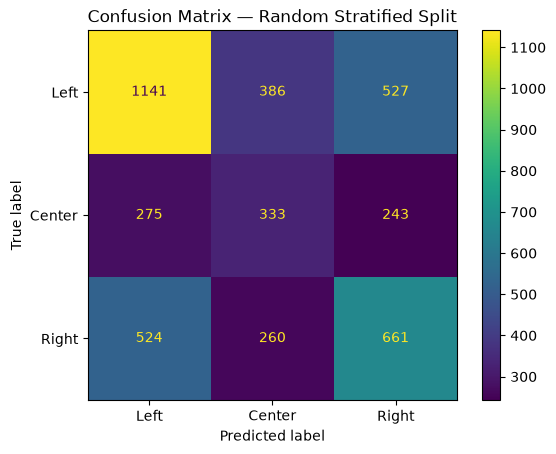


=============== Event-Disjoint Split ===============
Accuracy: 0.5237
Macro-F1: 0.5011

Classification report:
              precision    recall  f1-score   support

        left       0.62      0.57      0.59      2048
      center       0.38      0.44      0.41       856
       right       0.50      0.50      0.50      1448

    accuracy                           0.52      4352
   macro avg       0.50      0.51      0.50      4352
weighted avg       0.53      0.52      0.53      4352



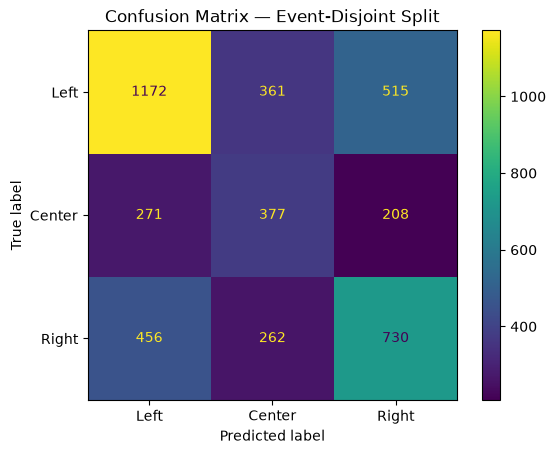


=============== Source-Disjoint Split ===============
Accuracy: 0.2763
Macro-F1: 0.2775

Classification report:
              precision    recall  f1-score   support

        left       0.12      0.37      0.18       459
      center       0.45      0.17      0.24      1349
       right       0.45      0.38      0.41       990

    accuracy                           0.28      2798
   macro avg       0.34      0.31      0.28      2798
weighted avg       0.39      0.28      0.29      2798



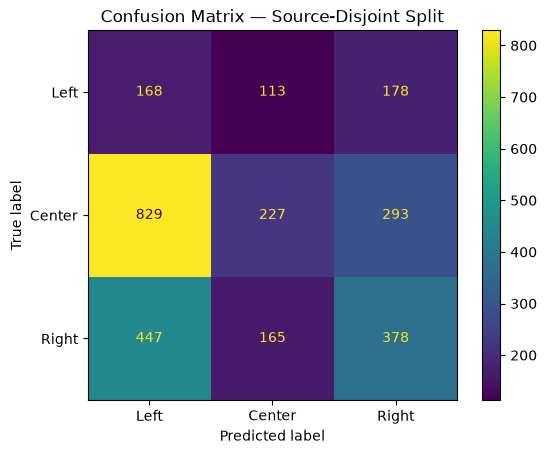

In [19]:
random_model = evaluate_model(
    X_train_random, y_train_random,
    X_test_random, y_test_random,
    "Random Stratified Split"
)

event_model = evaluate_model(
    X_train_event, y_train_event,
    X_test_event, y_test_event,
    "Event-Disjoint Split"
)

source_model = evaluate_model(
    X_train_source, y_train_source,
    X_test_source, y_test_source,
    "Source-Disjoint Split"
)